In [1]:
from pathlib import Path

from visual_inspection.features import create_feature_extractor

model, preprocess = create_feature_extractor()

In [2]:
from visual_inspection.data import (
    build_dataset_index,
    split_normal_train_validation,
    validate_dataset_index,
)

data_dir = Path("../data/bottle")

record_df = build_dataset_index(data_dir)
validate_dataset_index(record_df)

train_df, validation_df = split_normal_train_validation(
    record_df,
    validation_size=0.2,
    random_state=42,
)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(validation_df)}")

Train samples: 167
Validation samples: 42


In [3]:
from visual_inspection.features import extract_dataset_features

train_features = extract_dataset_features(
    train_df,
    model,
    preprocess,
)

validation_features = extract_dataset_features(
    validation_df,
    model,
    preprocess,
)

print(train_features.shape)
print(validation_features.shape)

torch.Size([167, 512])
torch.Size([42, 512])


min: 2.409836530685425, max: 7.303411483764648, mean: 3.835040330886841, median: 3.639282464981079


<Axes: ylabel='Count'>

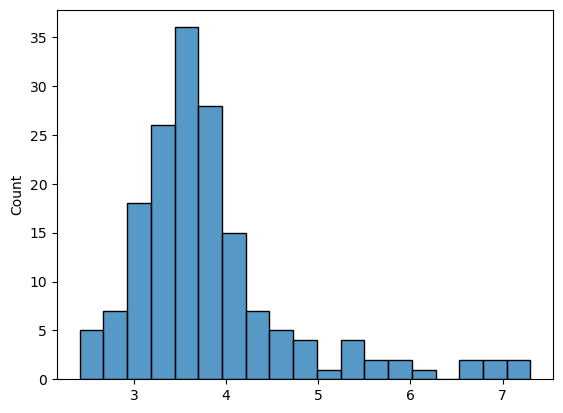

In [4]:
import seaborn as sns

from visual_inspection.scoring import centroid_anomaly_score

centroid_train_scores = centroid_anomaly_score(train_features, train_features)

print(
    f"min: {centroid_train_scores.min()}, max: {centroid_train_scores.max()}, mean: {centroid_train_scores.mean()}, median: {centroid_train_scores.median()}"
)

sns.histplot(centroid_train_scores)

min: 2.7796499729156494, max: 6.642104148864746, mean: 4.0799641609191895, median: 3.681889533996582


<Axes: ylabel='Count'>

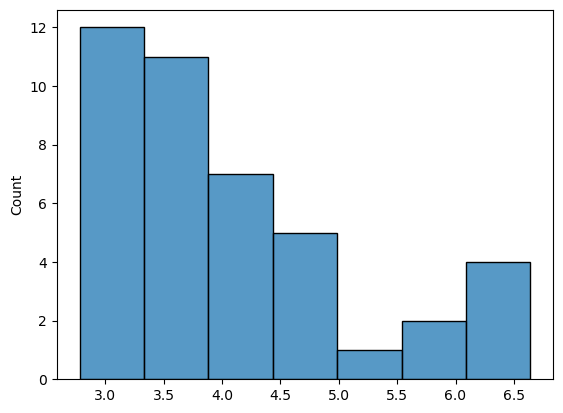

In [5]:
centroid_validation_scores = centroid_anomaly_score(train_features, validation_features)

print(
    f"min: {centroid_validation_scores.min()}, max: {centroid_validation_scores.max()}, mean: {centroid_validation_scores.mean()}, median: {centroid_validation_scores.median()}"
)

sns.histplot(centroid_validation_scores)

min: 2.2574105262756348, max: 4.9820637702941895, mean: 2.9856324195861816, median: 2.9228570461273193


<Axes: ylabel='Count'>

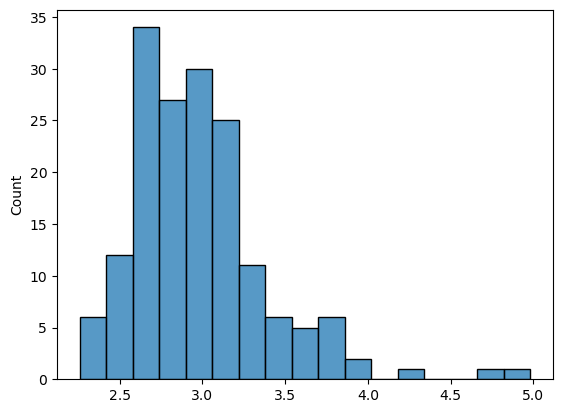

In [6]:
import seaborn as sns

from visual_inspection.scoring import knn_anomaly_score

knn_train_scores = knn_anomaly_score(train_features, train_features)

print(
    f"min: {knn_train_scores.min()}, max: {knn_train_scores.max()}, mean: {knn_train_scores.mean()}, median: {knn_train_scores.median()}"
)

sns.histplot(knn_train_scores)

min: 3.1287682056427, max: 5.295838356018066, mean: 3.8592419624328613, median: 3.7206509113311768


<Axes: ylabel='Count'>

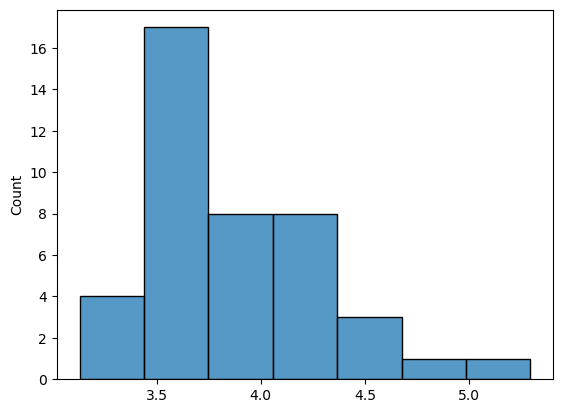

In [7]:
knn_validation_scores = knn_anomaly_score(train_features, validation_features)

print(
    f"min: {knn_validation_scores.min()}, max: {knn_validation_scores.max()}, mean: {knn_validation_scores.mean()}, median: {knn_validation_scores.median()}"
)

sns.histplot(knn_validation_scores)

In [8]:
from visual_inspection.scoring import calibrate_threshold

centroid_threshold = calibrate_threshold(centroid_validation_scores, quantile=0.95)
knn_threshold = calibrate_threshold(knn_validation_scores, quantile=0.95)

print(f"Centroid threshold: {centroid_threshold}")
print(f"kNN threshold: {knn_threshold}")

print((centroid_validation_scores > centroid_threshold).sum())
print((knn_validation_scores > knn_threshold).sum())

Centroid threshold: 6.149450778961182
kNN threshold: 4.555473804473877
tensor(3)
tensor(3)


In [9]:
from visual_inspection.artifacts import save_model_artifact

artifact_path = Path("../artifacts/bottle_knn_model.pt")

save_model_artifact(
    path=artifact_path,
    reference_features=train_features,
    threshold=knn_threshold,
    k=5,
    method="knn_distance",
    category="bottle",
)

print(f"Saved model artifact to {artifact_path}")

Saved model artifact to ..\artifacts\bottle_knn_model.pt


In [10]:
test_df = record_df[record_df["split"] == "test"].reset_index(drop=True)

test_features = extract_dataset_features(
    test_df,
    model,
    preprocess,
)

print(test_features.shape)

torch.Size([83, 512])


min: 3.016201972961426, max: 15.013162612915039, mean: 7.9329633712768555, median: 7.296926975250244
tensor(50)


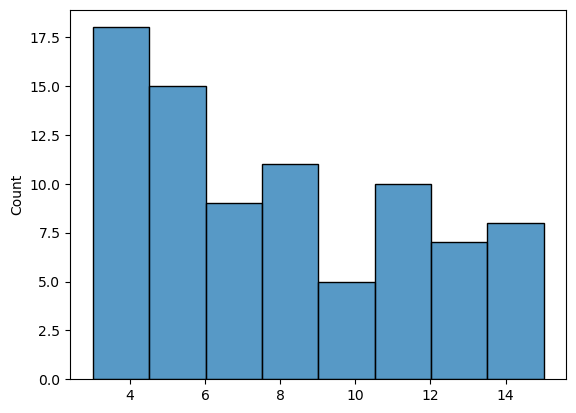

In [11]:
centroid_test_scores = centroid_anomaly_score(train_features, test_features)

print(
    f"min: {centroid_test_scores.min()}, max: {centroid_test_scores.max()}, mean: {centroid_test_scores.mean()}, median: {centroid_test_scores.median()}"
)

sns.histplot(centroid_test_scores)

print((centroid_test_scores > centroid_threshold).sum())

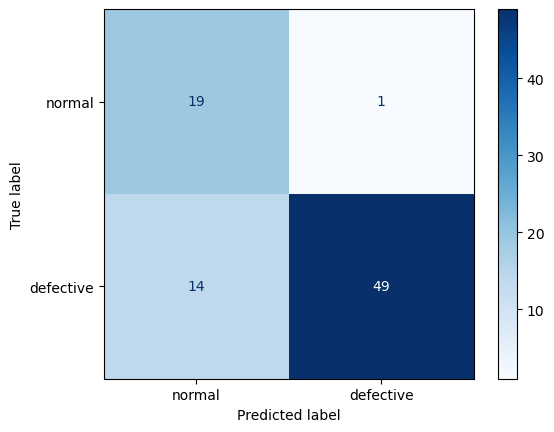

array([[19,  1],
       [14, 49]])

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from visual_inspection.scoring import predict_from_scores

y_true = test_df["label"]
y_pred = predict_from_scores(centroid_test_scores, centroid_threshold)

cm = confusion_matrix(y_true, y_pred, labels=["normal", "defective"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal", "defective"],
)

disp.plot(cmap="Blues")
plt.show()

cm

In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        labels=["normal", "defective"],
        target_names=["normal", "defective"],
    )
)

              precision    recall  f1-score   support

      normal       0.58      0.95      0.72        20
   defective       0.98      0.78      0.87        63

    accuracy                           0.82        83
   macro avg       0.78      0.86      0.79        83
weighted avg       0.88      0.82      0.83        83



In [14]:
test_results_df = test_df.copy()
test_results_df["centroid_score"] = centroid_test_scores.numpy()
test_results_df["prediction"] = y_pred

test_results_df.groupby(["defect_type", "label"])["centroid_score"].agg(
    ["count", "min", "mean", "median", "max"]
)

,,count,min,mean,median,max
defect_type,label,,,,,
broken_large,defective,20,5.324780,10.402051,11.078012,14.686832
broken_small,defective,22,4.154291,6.889741,6.645378,10.370081
contamination,defective,21,4.727678,10.390237,11.479595,15.013163
good,normal,20,3.016202,4.031281,3.791500,7.682034


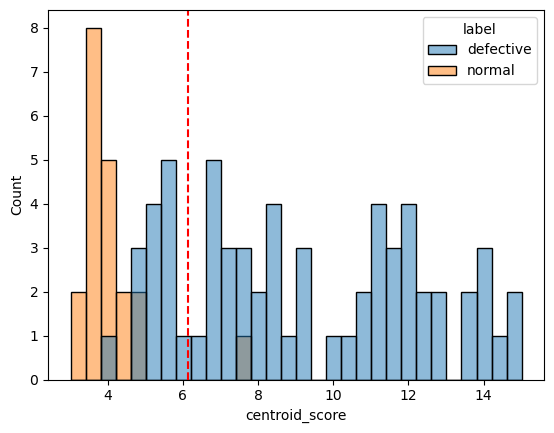

In [15]:
sns.histplot(
    data=test_results_df,
    x="centroid_score",
    hue="label",
    bins=30,
)

plt.axvline(float(centroid_threshold), color="red", linestyle="--")
plt.show()

In [16]:
test_results_df["is_correct"] = (
    test_results_df["label"] == test_results_df["prediction"]
)

test_results_df.groupby(["defect_type", "label", "prediction"]).size()

defect_type    label      prediction
broken_large   defective  defective     19
                          normal         1
broken_small   defective  defective     12
                          normal        10
contamination  defective  defective     18
                          normal         3
good           normal     defective      1
                          normal        19
dtype: int64

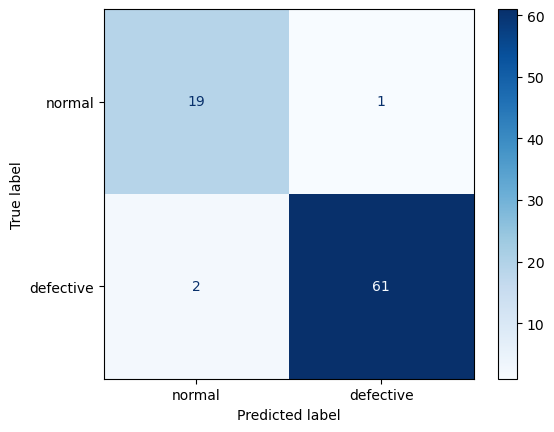

array([[19,  1],
       [ 2, 61]])

In [17]:
knn_test_scores = knn_anomaly_score(train_features, test_features)

knn_y_pred = predict_from_scores(knn_test_scores, knn_threshold)

cm = confusion_matrix(y_true, knn_y_pred, labels=["normal", "defective"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal", "defective"],
)

disp.plot(cmap="Blues")
plt.show()

cm

In [18]:
print(
    classification_report(
        y_true,
        knn_y_pred,
        labels=["normal", "defective"],
        target_names=["normal", "defective"],
    )
)

              precision    recall  f1-score   support

      normal       0.90      0.95      0.93        20
   defective       0.98      0.97      0.98        63

    accuracy                           0.96        83
   macro avg       0.94      0.96      0.95        83
weighted avg       0.96      0.96      0.96        83



In [19]:
knn_results_df = test_df.copy()
knn_results_df["knn_score"] = knn_test_scores.numpy()
knn_results_df["prediction"] = knn_y_pred

knn_results_df.groupby(["defect_type", "label", "prediction"]).size()

defect_type    label      prediction
broken_large   defective  defective     20
broken_small   defective  defective     21
                          normal         1
contamination  defective  defective     20
                          normal         1
good           normal     defective      1
                          normal        19
dtype: int64

kNN distance is selected as the primary anomaly score for v0.1.
The threshold is calibrated on normal validation images only using the 95th percentile.
The final test evaluation reaches 96% accuracy, with 61/63 defective images detected and 1/20 normal images incorrectly flagged.